<a href="https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/ner/01-bioclinicalbert-baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description

To load this from remote:
```
from transformers import pipeline

# It will download once and cache it for future use
ner_pipe = pipeline("ner", model="alexd063/bio-clinicalbert-finetuned-medmentions")
results = ner_pipe("Patient shows symptoms of acute appendicitis.")
print(results)
```

In [ ]:
%%capture
!pip install transformers datasets evaluate seqeval accelerate torch numpy
!pip install --upgrade transformers

In [ ]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [ ]:
import torch
import numpy as np
import evaluate
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from seqeval.metrics import classification_report as seqeval_report
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
from huggingface_hub import notebook_login, whoami

In [ ]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

In [ ]:
PUSH_TO_HUB = False  # Set to False to skip login and hub push

if PUSH_TO_HUB:
    notebook_login()


In [ ]:
class Config:
    MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
    DATASET_ID = "Ben10x/MedMentions-MTI881-NER"
    HUB_REPO_ID = "alexd063/bio-clinicalbert-finetuned-medmentions"

    MAX_LENGTH = 512
    BATCH_SIZE = 16
    EPOCHS = 20
    LEARNING_RATE = 2e-5
    WARMUP_RATIO = 0.10
    WEIGHT_DECAY = 0.01

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()


In [ ]:
import time
notebook_start_time = time.time()


In [ ]:
# ------------------------------------------
# 1. Load Dataset & Extract Labels
# ------------------------------------------
dataset = load_dataset("Ben10x/MedMentions-MTI881-NER")

# the dataset stores tags as strings (e.g., 'B-T062', 'I-T062', 'O').
# need to extract all unique tags to create label mappings.
unique_tags = set()
for split in dataset.keys():
    for row in dataset[split]["ner_tags"]:
        unique_tags.update(row)

label_list = sorted(list(unique_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

# ------------------------------------------
# 2. Tokenization & Label Alignment
# ------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_ID)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=config.MAX_LENGTH
    )

    labels = []
    for i, label_sequence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # special tokens (like [CLS] and [SEP]) map to None. we set their label to -100 so they are ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # only label the first token of a given word.
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_sequence[word_idx]])
            # for subsequent tokens of the same word, also assign -100 (or you can assign the I- tag).
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

In [ ]:
%%capture
# capture widget output, github cannot show widgets.

# ------------------------------------------
# 3. Metrics
# ------------------------------------------

seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": np.round(results["overall_precision"], 3),
        "recall": np.round(results["overall_recall"], 3),
        "f1": np.round(results["overall_f1"], 3),
        "accuracy": np.round(results["overall_accuracy"], 3),
    }

In [ ]:
# ------------------------------------------
# 4. Training
# ------------------------------------------

training_args = TrainingArguments(
    output_dir="./bio-clinicalbert-medmentions",
    learning_rate=config.LEARNING_RATE,
    per_device_train_batch_size=config.BATCH_SIZE,
    per_device_eval_batch_size=config.BATCH_SIZE,
    num_train_epochs=config.EPOCHS,
    weight_decay=config.WEIGHT_DECAY,
    warmup_ratio=config.WARMUP_RATIO,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    hub_model_id=config.HUB_REPO_ID if PUSH_TO_HUB else None
)

model = AutoModelForTokenClassification.from_pretrained(
    config.MODEL_ID,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

trainer.save_model("./bio-clinicalbert-medmentions-final")

{'loss': '2.426', 'grad_norm': '2.558', 'learning_rate': '3.411e-06', 'epoch': '0.3418'}
{'loss': '0.9448', 'grad_norm': '4.431', 'learning_rate': '6.828e-06', 'epoch': '0.6835'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.6638', 'eval_precision': '0.438', 'eval_recall': '0.407', 'eval_f1': '0.422', 'eval_accuracy': '0.821', 'eval_runtime': '5.717', 'eval_samples_per_second': '511.5', 'eval_steps_per_second': '32.01', 'epoch': '1'}
{'loss': '0.7157', 'grad_norm': '3.159', 'learning_rate': '1.025e-05', 'epoch': '1.025'}
{'loss': '0.5955', 'grad_norm': '2.462', 'learning_rate': '1.366e-05', 'epoch': '1.367'}
{'loss': '0.5448', 'grad_norm': '2.825', 'learning_rate': '1.708e-05', 'epoch': '1.709'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.507', 'eval_precision': '0.515', 'eval_recall': '0.547', 'eval_f1': '0.531', 'eval_accuracy': '0.845', 'eval_runtime': '5.652', 'eval_samples_per_second': '517.4', 'eval_steps_per_second': '32.38', 'epoch': '2'}
{'loss': '0.5014', 'grad_norm': '1.89', 'learning_rate': '2e-05', 'epoch': '2.051'}
{'loss': '0.4362', 'grad_norm': '4.755', 'learning_rate': '1.998e-05', 'epoch': '2.392'}
{'loss': '0.4231', 'grad_norm': '2.322', 'learning_rate': '1.992e-05', 'epoch': '2.734'}


...

{'eval_loss': '0.7139', 'eval_precision': '0.628', 'eval_recall': '0.663', 'eval_f1': '0.645', 'eval_accuracy': '0.883', 'eval_runtime': '5.541', 'eval_samples_per_second': '527.7', 'eval_steps_per_second': '33.03', 'epoch': '17'}
{'loss': '0.02539', 'grad_norm': '2.411', 'learning_rate': '1.264e-06', 'epoch': '17.09'}
{'loss': '0.0241', 'grad_norm': '1.794', 'learning_rate': '9.898e-07', 'epoch': '17.43'}
{'loss': '0.02417', 'grad_norm': '3.328', 'learning_rate': '7.472e-07', 'epoch': '17.77'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.7184', 'eval_precision': '0.629', 'eval_recall': '0.662', 'eval_f1': '0.645', 'eval_accuracy': '0.882', 'eval_runtime': '5.492', 'eval_samples_per_second': '532.4', 'eval_steps_per_second': '33.32', 'epoch': '18'}
{'loss': '0.02479', 'grad_norm': '1.734', 'learning_rate': '5.376e-07', 'epoch': '18.11'}
{'loss': '0.02294', 'grad_norm': '3.463', 'learning_rate': '3.616e-07', 'epoch': '18.46'}
{'loss': '0.02196', 'grad_norm': '2.104', 'learning_rate': '2.199e-07', 'epoch': '18.8'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.7228', 'eval_precision': '0.627', 'eval_recall': '0.664', 'eval_f1': '0.645', 'eval_accuracy': '0.882', 'eval_runtime': '5.459', 'eval_samples_per_second': '535.6', 'eval_steps_per_second': '33.52', 'epoch': '19'}
{'train_runtime': '1484', 'train_samples_per_second': '315.3', 'train_steps_per_second': '19.71', 'train_loss': '0.2103', 'epoch': '19'}


In [ ]:
# ------------------------------------------
# 5. Assessment on Test Set
# ------------------------------------------

test_results = trainer.evaluate(tokenized_datasets["test"])

print("Test Set Evaluation Result")
for key, value in test_results.items():
    metric_name = key.replace("eval_", "")
    print(f"{metric_name:10}: {value:.4f}")

# specific examples
# predictions, labels, metrics = trainer.predict(tokenized_datasets["test"])
# print("\nDetailed Test Metrics:", metrics)

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.6913', 'eval_precision': '0.631', 'eval_recall': '0.673', 'eval_f1': '0.652', 'eval_accuracy': '0.886', 'eval_runtime': '5.535', 'eval_samples_per_second': '528.6', 'eval_steps_per_second': '33.06', 'epoch': '19'}
Test Set Evaluation Result
loss      : 0.6913
precision : 0.6310
recall    : 0.6730
f1        : 0.6520
accuracy  : 0.8860
runtime   : 5.5354
samples_per_second: 528.5960
steps_per_second: 33.0600
epoch     : 19.0000


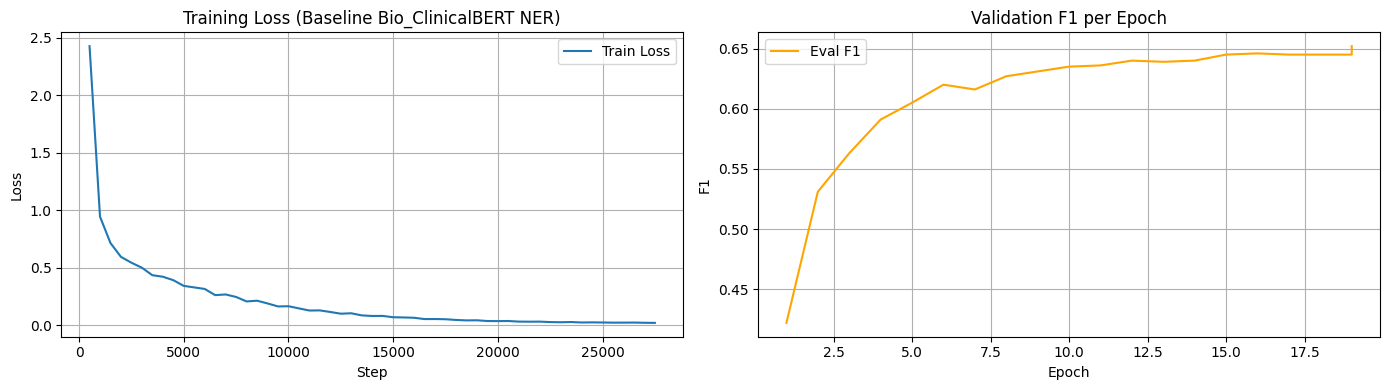

Saved: ner_training_curves_baseline.png


In [ ]:
# ------------------------------------------
# 6. Training Curves
# ------------------------------------------
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x and 'eval_loss' not in x]
train_steps = [x['step'] for x in history if 'loss' in x and 'eval_loss' not in x]

eval_f1 = [x['eval_f1'] for x in history if 'eval_f1' in x]
eval_epochs = [x['epoch'] for x in history if 'eval_f1' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_steps, train_loss, label='Train Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Baseline Bio_ClinicalBERT NER)')
axes[0].legend()
axes[0].grid(True)

if eval_f1:
    axes[1].plot(eval_epochs, eval_f1, color='orange', label='Eval F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1')
    axes[1].set_title('Validation F1 per Epoch')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()
plt.savefig('ner_training_curves_baseline.png')
plt.show()
print("Saved: ner_training_curves_baseline.png")

------------------------------------------------------------
Per-Entity Classification Report (Test Set)
------------------------------------------------------------
              precision    recall  f1-score   support

        T005       0.37      0.64      0.47        11
        T007       0.55      0.40      0.47        52
        T017       0.67      0.72      0.70      1219
        T022       0.17      0.10      0.12        10
        T023       0.33      0.22      0.27         9
        T025       0.00      0.00      0.00         3
        T028       0.00      0.00      0.00         5
        T031       0.54      0.29      0.38        24
        T033       0.45      0.50      0.47       957
        T037       0.56      0.61      0.58        41
        T038       0.68      0.74      0.71      2478
        T044       0.00      0.00      0.00         9
        T046       0.50      0.20      0.29         5
        T047       0.56      0.52      0.54        27
        T048       0.67

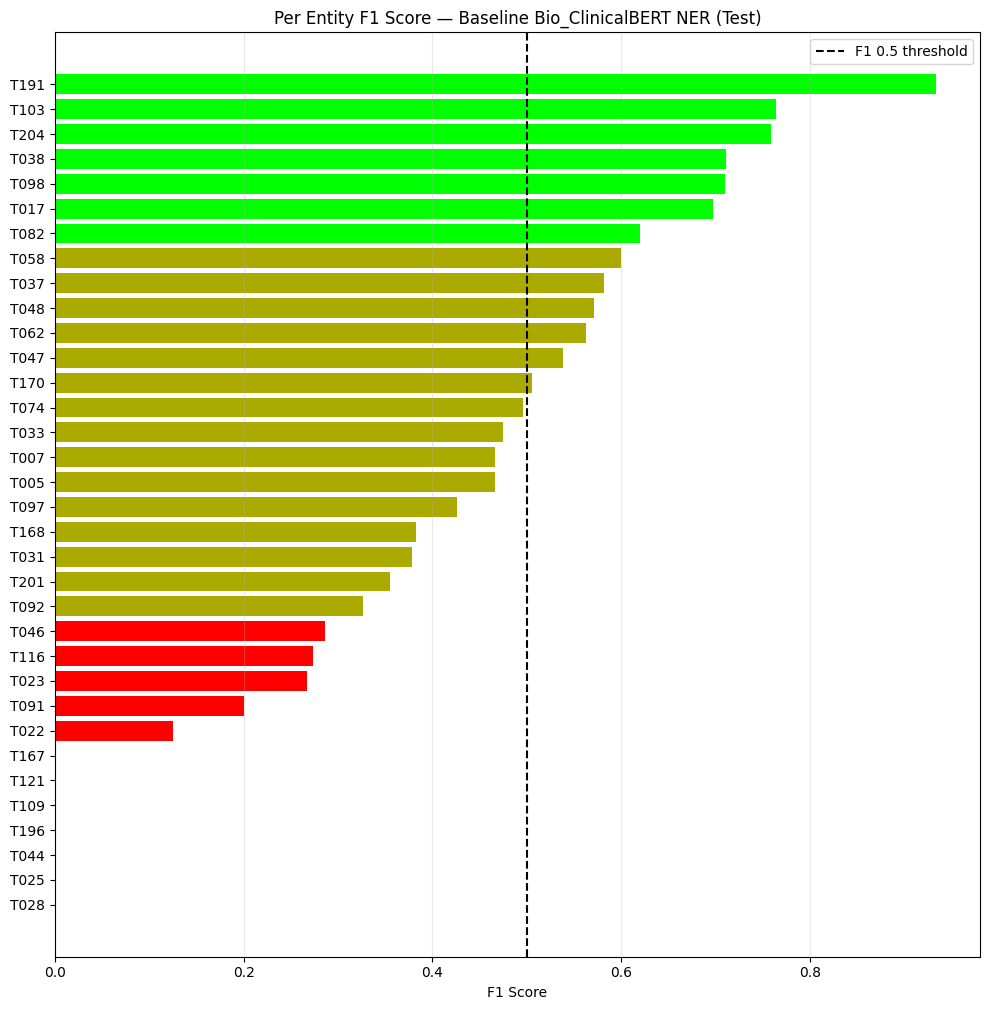

Saved: ner_per_entity_f1_baseline.png


In [ ]:
# ------------------------------------------
# 7. Per-Entity-Type Analysis on Test Set
# ------------------------------------------
import pandas as pd

test_predictions, test_labels_raw, _ = trainer.predict(tokenized_datasets["test"])
test_predictions_ids = np.argmax(test_predictions, axis=2)

true_labels = []
true_predictions = []
for pred_row, label_row in zip(test_predictions_ids, test_labels_raw):
    true_pred = []
    true_lab = []
    for p, l in zip(pred_row, label_row):
        if l != -100:
            true_pred.append(id2label[p])
            true_lab.append(id2label[l])
    true_predictions.append(true_pred)
    true_labels.append(true_lab)

print("-" * 60)
print("Per-Entity Classification Report (Test Set)")
print("-" * 60)
print(seqeval_report(true_labels, true_predictions))

# Per entity f1
report_dict = seqeval_report(true_labels, true_predictions, output_dict=True)
rows = []
for entity, metrics in report_dict.items():
    if isinstance(metrics, dict) and entity not in ('micro avg', 'macro avg', 'weighted avg'):
        rows.append({'entity': entity, 'f1': metrics['f1-score'], 'support': metrics['support']})

df_report = pd.DataFrame(rows).sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_report) * 0.3)))
colors = ['#ff0000' if f < 0.3 else '#aaaa00' if f < 0.6 else '#00ff00' for f in df_report['f1']]
ax.barh(df_report['entity'], df_report['f1'], color=colors)
ax.axvline(x=0.5, color='black', linestyle='--', label='F1 0.5 threshold')
ax.set_xlabel('F1 Score')
ax.set_title('Per Entity F1 Score — Baseline Bio_ClinicalBERT NER (Test)')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ner_per_entity_f1_baseline.png')
plt.show()
print("Saved: ner_per_entity_f1_baseline.png")

In [ ]:
notebook_end_time = time.time()
elapsed = notebook_end_time - notebook_start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook execution time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

# it took less in actuality, this cell was ran manually for the last run


Total notebook execution time: 00:33:08


In [ ]:
# ------------------------------------------
# 7. Push to Hugging Face Hub
# ------------------------------------------

if PUSH_TO_HUB:
    trainer.push_to_hub(
        commit_message="End of training",
        finetuned_from=config.MODEL_ID,
        dataset=config.DATASET_ID
    )
    tokenizer.push_to_hub(repo_id=config.HUB_REPO_ID)

    # sanity check: run inference from the remote model
    from transformers import pipeline

    ner_pipe = pipeline("ner", model=config.HUB_REPO_ID)
    results = ner_pipe("Patient shows symptoms of acute appendicitis.")
    print(results)

No files have been modified since last commit. Skipping to prevent empty commit.


[{'entity': 'B-T033', 'score': np.float32(0.9997615), 'index': 3, 'word': 'symptoms', 'start': 14, 'end': 22}, {'entity': 'B-T038', 'score': np.float32(0.99986625), 'index': 5, 'word': 'acute', 'start': 26, 'end': 31}, {'entity': 'I-T038', 'score': np.float32(0.99989533), 'index': 6, 'word': 'app', 'start': 32, 'end': 35}, {'entity': 'I-T038', 'score': np.float32(0.9998907), 'index': 7, 'word': '##end', 'start': 35, 'end': 38}, {'entity': 'I-T038', 'score': np.float32(0.9999027), 'index': 8, 'word': '##icit', 'start': 38, 'end': 42}, {'entity': 'I-T038', 'score': np.float32(0.9998988), 'index': 9, 'word': '##is', 'start': 42, 'end': 44}]
